In [4]:
#数据获取
import baostock as bs
import pandas as pd
import os
import datetime

class StockDataLoader:
    def __init__(self, stock_code, start_date, end_date=None, data_dir='./data'):
        self.stock_code = stock_code
        self.start_date = start_date
        self.end_date = end_date if end_date else datetime.datetime.now().strftime('%Y-%m-%d')
        self.data_dir = data_dir
        
        if not os.path.exists(self.data_dir):
            os.makedirs(self.data_dir)
            
        self.file_path = os.path.join(self.data_dir, f"{stock_code}_{start_date}_{self.end_date}.csv")

    def _clean_raw_data(self, df):
        """
        内部清洗逻辑：确保无论如何都返回一个 DataFrame
        """
        # 1. 拷贝一份，防止修改原始引用带来的隐患
        df = df.copy()
        
        # 2. 类型转换
        numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
        # 确保这些列存在，防止 KeyError
        valid_cols = [c for c in numeric_cols if c in df.columns]
        df[valid_cols] = df[valid_cols].apply(pd.to_numeric, errors='coerce')

        # 3. 时间标准化
        if 'time' in df.columns:
            df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S%f')
            df = df.set_index('time').sort_index()
        
        # 4. 删除多余列
        if 'date' in df.columns:
            df = df.drop(columns=['date'])
            
        # 【关键】必须在所有缩进块之外返回 df
        return df

    def download_data(self, frequency="5"):
        # 1. 检查本地缓存
        if os.path.exists(self.file_path):
            print(f"检测到本地缓存: {self.file_path}")
            try:
                df = pd.read_csv(self.file_path, index_col='time', parse_dates=['time'])
                print(f"本地数据加载成功，行数: {len(df)}")
                return df
            except Exception as e:
                print(f"本地文件读取失败 ({e})，准备重新下载...")

        # 2. Baostock 下载
        print(f"正在连接 Baostock 下载 {self.stock_code}...")
        bs.login()
        
        rs = bs.query_history_k_data_plus(
            self.stock_code,
            "date,time,open,high,low,close,volume,amount",
            start_date=self.start_date, 
            end_date=self.end_date,
            frequency=frequency, 
            adjustflag="2"
        )

        data_list = []
        while rs.next():
            data_list.append(rs.get_row_data())
        
        bs.logout()

        if not data_list:
            raise ValueError(f"Baostock 未返回任何数据! 请检查:\n1. 股票代码是否正确 (如 'sh.600519')\n2. 日期范围 ({self.start_date} 是否在上市后)\n3. 是否是交易日")

        # 3. 转换为 DataFrame
        df = pd.DataFrame(data_list, columns=rs.fields)
        
        # 4. 执行清洗
        df = self._clean_raw_data(df)
        
        # 【防御性检查】确保清洗后 df 依然存在
        if df is None:
            raise ValueError("严重错误：_clean_raw_data 返回了 None，请检查代码缩进！")

        # 5. 保存
        try:
            df.to_csv(self.file_path)
            print(f"数据已下载并清洗，保存至: {self.file_path}")
        except Exception as e:
            print(f"警告: 数据保存失败 ({e})，但将返回内存中的 DataFrame")

        return df

    def resample_data(self, df, rule='60min'):
        """
        重采样：从 5分钟 (含噪音) -> 小时/日线 (趋势)
        """
        # 确保 df 索引是时间类型
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
            
        agg_dict = {
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum',
            'amount': 'sum'
        }
        
        # 仅对存在的列进行聚合
        valid_agg = {k: v for k, v in agg_dict.items() if k in df.columns}
        
        df_res = df.resample(rule, label='right', closed='right').agg(valid_agg)
        df_res = df_res.dropna()
        
        print(f"重采样完成: {len(df)} (原始) -> {len(df_res)} ({rule})")
        return df_res



In [5]:
#只有从2019开始的分钟线数据
Data=StockDataLoader("sh.600519", "2019-01-01").download_data()
df_raw = Data
df_raw

检测到本地缓存: ./data\sh.600519_2019-01-01_2026-01-26.csv
本地数据加载成功，行数: 82272


,open,high,low,close,volume,amount
time,,,,,,
2019-01-02 09:35:00,520.781405,522.506016,516.529640,519.517828,1552766,945850400.0
2019-01-02 09:40:00,519.577592,520.798480,517.511473,517.554162,395656,240900640.0
2019-01-02 09:45:00,517.383408,518.237176,515.564882,515.803937,332316,201314560.0
2019-01-02 09:50:00,516.179595,516.529640,514.156165,516.145444,201370,121501600.0
2019-01-02 09:55:00,516.145444,516.529640,511.407032,511.483871,361837,217579824.0
...,...,...,...,...,...,...
2026-01-23 14:40:00,1335.360000,1336.770000,1332.710000,1334.000000,581350,775614285.0
2026-01-23 14:45:00,1334.380000,1337.650000,1334.380000,1337.170000,91407,122180265.0
2026-01-23 14:50:00,1337.160000,1337.280000,1334.380000,1335.200000,194476,259865095.0


In [9]:
#特征工程

import pandas as pd
import numpy as np

def perform_feature_engineering(df_raw):
    """
    输入: df_raw (5分钟原始数据, 含噪音 g(t))
    输出: X (特征矩阵), y (标签), df_final (用于分析的完整数据)
    """
    
    # ==========================================
    # 1. 物理降噪：重采样为 60分钟线
    # ==========================================
    # A股每天4小时交易，60min线每天4根。
    # 这相当于从物理上滤除了频率高于 1/4天 的 g(t) 噪音
    agg_dict = {
        'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last',
        'volume': 'sum', 'amount': 'sum'
    }
    # 确保索引是datetime
    if not isinstance(df_raw.index, pd.DatetimeIndex):
        df_raw.index = pd.to_datetime(df_raw.index)
        
    df = df_raw.resample('60min', closed='right', label='right').agg(agg_dict).dropna()
    print(f"数据重采样完成: {len(df_raw)} (5min) -> {len(df)} (60min)")

    # ==========================================
    # 2. 构造描述 f(t) 的特征
    # ==========================================
    
    # --- A. 均线系统 (拟合 f(t)) ---
    # MA5 (短期，约1天多), MA20 (中期，约1周), MA60 (长期，约3周)
    # 注意：这里的周期是 60min K线的根数
    df['ma_5'] = df['close'].rolling(window=5).mean()
    df['ma_20'] = df['close'].rolling(window=20).mean()   # 近似 f(t)
    df['ma_60'] = df['close'].rolling(window=60).mean()   # 更平滑的 f(t)
    
    # --- B. 趋势斜率 (Derivative of f(t)) ---
    # 计算均线的变化率，而不是价格的变化率
    # 逻辑：如果 ma_60 的斜率 > 0，说明长期趋势向上
    def calculate_slope(series, period=3):
        return (series - series.shift(period)) / series.shift(period)

    df['slope_ma5'] = calculate_slope(df['ma_5'])
    df['slope_ma20'] = calculate_slope(df['ma_20']) # 核心特征
    df['slope_ma60'] = calculate_slope(df['ma_60']) # 核心特征
    
    # --- C. 均线纠缠/发散 (Convergence/Divergence) ---
    # 短期均线相对于长期均线的位置
    df['dist_ma5_ma20'] = (df['ma_5'] - df['ma_20']) / df['ma_20']
    df['dist_ma20_ma60'] = (df['ma_20'] - df['ma_60']) / df['ma_60']
    
    # --- D. 相对波动率 (用于动态阈值) ---
    # ATR 计算
    high_low = df['high'] - df['low']
    high_close = np.abs(df['high'] - df['close'].shift())
    low_close = np.abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df['atr'] = true_range.rolling(window=20).mean()
    # 归一化波动率 (ATR%)
    df['atr_pct'] = df['atr'] / df['close']

    # --- E. 动量特征 (RSI on MA) ---
    # 对平滑后的 ma_20 计算 RSI，而不是对 close 计算
    # 这能避免因 g(t) 导致的 RSI 频繁钝化
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    df['rsi_ma20'] = calculate_rsi(df['ma_20'], window=14)

    # --- F. 滞后特征 (Lagging Features) ---
    # 这里的关键是：让模型看到“过去 N 小时” f(t) 是如何变化的
    # 我们不再输入原始价格，而是输入“斜率的历史”
    feature_cols_base = ['slope_ma20', 'slope_ma60', 'dist_ma5_ma20', 'dist_ma20_ma60', 'atr_pct', 'rsi_ma20']
    
    lags = [1, 2, 4, 8] # 回看过去 1, 2, 4, 8 个小时的情况
    for col in feature_cols_base:
        for lag in lags:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)

    # ==========================================
    # 3. 标签生成 (Robust Labeling)
    # ==========================================
    # 目的：确定当前时刻 f(t) 的涨跌趋势
    # 方法：比较 "未来 N 周期均价" 与 "当前 N 周期均价"
    # 牺牲时间：预测未来 8 个周期 (约2个交易日) 后的趋势
    
    prediction_horizon = 8  # 预测未来 8 小时
    smooth_window = 4       # 使用 4 小时均价来代表 f(t)，消除单点 g(t) 干扰
    
    # 当前平滑价格
    curr_smooth = df['close'].rolling(window=smooth_window).mean()
    # 未来平滑价格 (shift负数表示读取未来数据)
    future_smooth = df['close'].rolling(window=smooth_window).mean().shift(-prediction_horizon)
    
    # 计算趋势收益率
    df['trend_return'] = (future_smooth - curr_smooth) / curr_smooth
    
    # 动态阈值：要求趋势收益必须大于 0.8 倍的 ATR (波动幅度)
    # 这样只有当 f(t) 的变化显著大于 g(t) 的噪音时，才标记为趋势
    threshold = df['atr_pct'] * 0.8
    
    # 定义标签
    # 2: 明显上涨 (Trend Up)
    # 1: 明显下跌 (Trend Down)
    # 0: 震荡/不确定 (Noise/Sideways)
    
    conditions = [
        (df['trend_return'] > threshold),   # 上涨
        (df['trend_return'] < -threshold)   # 下跌
    ]
    choices = [2, 1]
    df['label'] = np.select(conditions, choices, default=0)

    # ==========================================
    # 4. 清洗与输出
    # ==========================================
    # 移除包含 NaN 的行 (因为计算 MA 和 shift 产生的)
    df_final = df.dropna()
    
    # 提取特征列
    # 排除所有以 'close', 'open', 'high', 'low', 'volume' 开头的原始列
    # 只保留我们计算出的衍生特征
    exclude_keywords = ['open', 'high', 'low', 'close', 'volume', 'amount', 'ma_', 'label', 'trend_return', 'atr']
    feature_cols = [c for c in df_final.columns if not any(k == c for k in exclude_keywords)]
    # 注意：我们保留 slope, dist, lag 等特征，剔除原始绝对价格
    
    print("\n特征工程完成。")
    print(f"最终样本数: {len(df_final)}")
    print(f"标签分布:\n{df_final['label'].value_counts(normalize=True)}")
    print(f"特征列表 (前10个): {feature_cols[:10]} ... 总共 {len(feature_cols)} 个特征")
    
    X = df_final[feature_cols]
    y = df_final['label']
    
    return X, y, df_final

# 假设 df_raw 已经存在 (来自上一步)
# 执行特征工程
if 'df_raw' in locals():
    X, y, df_clean = perform_feature_engineering(df_raw)
else:
    print("请先运行数据获取代码以生成 df_raw")

X,y,df_clean

数据重采样完成: 82272 (5min) -> 8570 (60min)

特征工程完成。
最终样本数: 8492
标签分布:
label
0    0.341027
2    0.333490
1    0.325483
Name: proportion, dtype: float64
特征列表 (前10个): ['ma_5', 'ma_20', 'ma_60', 'slope_ma5', 'slope_ma20', 'slope_ma60', 'dist_ma5_ma20', 'dist_ma20_ma60', 'atr_pct', 'rsi_ma20'] ... 总共 34 个特征


(                            ma_5        ma_20        ma_60  slope_ma5  \
 time                                                                    
 2019-01-22 10:00:00   584.282961   574.836445   545.003372  -0.003059   
 2019-01-22 11:00:00   581.737025   575.513056   546.079973  -0.008596   
 2019-01-22 12:00:00   579.508690   576.059468   547.045870  -0.013361   
 2019-01-22 14:00:00   576.947386   576.304926   547.966943  -0.012555   
 2019-01-22 15:00:00   574.218744   576.727541   548.948776  -0.012924   
 ...                          ...          ...          ...        ...   
 2026-01-21 12:00:00  1368.584000  1378.906000  1404.783833  -0.004883   
 2026-01-21 14:00:00  1366.118000  1377.399500  1403.795833  -0.005739   
 2026-01-21 15:00:00  1361.620000  1375.508000  1402.546833  -0.007097   
 2026-01-22 10:00:00  1360.210000  1374.092500  1401.450167  -0.006119   
 2026-01-22 11:00:00  1357.598000  1372.317500  1400.261500  -0.006237   
 
                      slope_ma20  sl

开始训练... 样本总数: 8492
Fold 1 - 验证集区间: 2020-03-25 12:00:00 至 2021-05-26 11:00:00
    --> 上涨查准率: 30.58% | 下跌查准率: 26.86%
Fold 2 - 验证集区间: 2021-05-26 12:00:00 至 2022-07-25 11:00:00
    --> 上涨查准率: 39.66% | 下跌查准率: 44.00%
Fold 3 - 验证集区间: 2022-07-25 12:00:00 至 2023-09-19 11:00:00
    --> 上涨查准率: 36.17% | 下跌查准率: 42.29%
Fold 4 - 验证集区间: 2023-09-19 12:00:00 至 2024-11-25 11:00:00
    --> 上涨查准率: 23.29% | 下跌查准率: 42.51%
Fold 5 - 验证集区间: 2024-11-25 12:00:00 至 2026-01-22 11:00:00
    --> 上涨查准率: 35.98% | 下跌查准率: 35.64%

平均趋势预测查准率: 35.70%

最终模型特征重要性 (Top 10):
               Feature  Importance
6        dist_ma5_ma20           4
3            slope_ma5           4
1                ma_20           3
0                 ma_5           3
7       dist_ma20_ma60           3
2                ma_60           3
19  dist_ma5_ma20_lag2           3
8              atr_pct           2
17     slope_ma60_lag8           2
15     slope_ma60_lag2           2


c:\Users\xyp\Desktop\机器学习预测股价趋势\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyp\Desktop\机器学习预测股价趋势\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyp\Desktop\机器学习预测股价趋势\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyp\Desktop\机器学习预测股价趋势\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyp\Desktop\机器学习预测股价趋势\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615

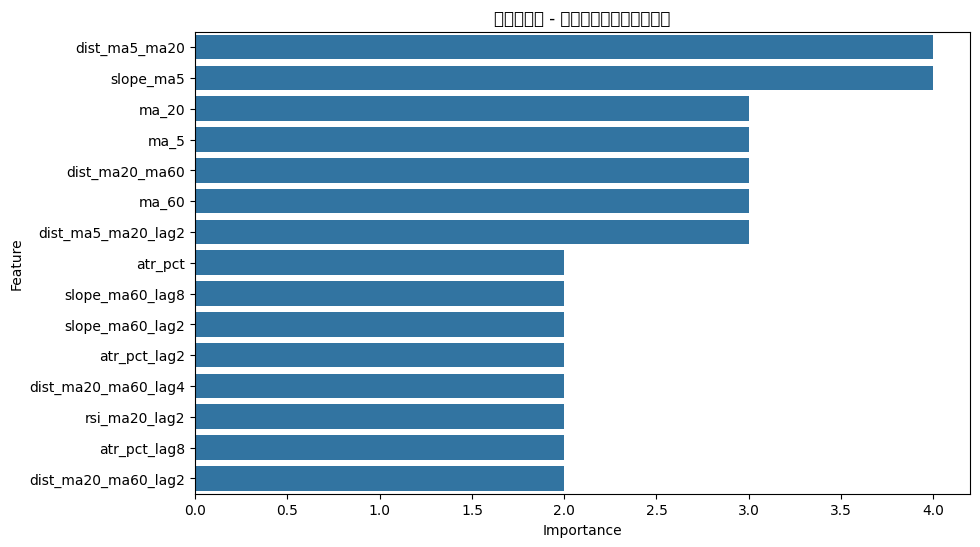

In [14]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def train_trend_model(X, y):
    """
    训练 LightGBM 模型，专注于高精度的趋势捕捉
    """
    # ==========================================
    # 1. 准备时间序列交叉验证
    # ==========================================
    # 5折交叉验证，每一折都严格保证 训练集时间 < 验证集时间
    # 这样能模拟真实的回测场景
    tscv = TimeSeriesSplit(n_splits=5)
    
    # 存储每一折的评估结果
    fold_precisions = []
    models = []
    
    print(f"开始训练... 样本总数: {len(X)}")
    
    for fold, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # ==========================================
        # 2. 模型参数设置 (针对去噪优化)
        # ==========================================
        params = {
            'objective': 'multiclass',
            'num_class': 3,
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            'n_jobs': -1,
            'random_state': 42,
            
            # --- 抗过拟合核心 ---
            'learning_rate': 0.03,      # 降低学习率，让模型学得更精细
            'num_leaves': 20,           # 控制树的复杂度，避免死记硬背 g(t)
            'max_depth': 5,             # 限制深度
            'min_child_samples': 30,    # 叶子节点最少样本数，过滤掉偶然的噪音波动
            
            # --- 特征抽样 ---
            'colsample_bytree': 0.7,    # 每次只看70%的特征，强迫模型综合判断
            'subsample': 0.7,           # 每次只看70%的数据
            'subsample_freq': 1,
            
            # --- 类别权重 ---
            # 'balanced' 会自动增加少数类(趋势)的权重
            # 这对捕捉 f(t) 至关重要，因为趋势往往比震荡少
            'class_weight': 'balanced', 
            'verbose': -1
        }
        
        # ==========================================
        # 3. 训练
        # ==========================================
        model = lgb.LGBMClassifier(**params, n_estimators=1000)
        
        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0) # 不打印刷屏日志
        ]
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='multi_logloss',
            callbacks=callbacks
        )
        
        # ==========================================
        # 4. 单折验证
        # ==========================================
        y_pred = model.predict(X_val)
        
        # 我们最在乎的是：当模型说"涨"(2)时，是不是真的"涨"？
        # 即 Precision (查准率)。即使漏掉一些机会也没关系，但不能被噪音骗进去。
        prec_up = precision_score(y_val, y_pred, labels=[2], average='macro', zero_division=0)
        prec_down = precision_score(y_val, y_pred, labels=[1], average='macro', zero_division=0)
        
        print(f"Fold {fold+1} - 验证集区间: {X_val.index.min()} 至 {X_val.index.max()}")
        print(f"    --> 上涨查准率: {prec_up:.2%} | 下跌查准率: {prec_down:.2%}")
        
        fold_precisions.append((prec_up + prec_down) / 2)
        models.append(model)

    print("\n" + "="*50)
    print(f"平均趋势预测查准率: {np.mean(fold_precisions):.2%}")
    print("="*50)

    # ==========================================
    # 5. 使用最后一折的模型做最终详细评估
    # ==========================================
    # 取最后一个模型（见过最多数据的模型）
    final_model = models[-1]
    
    # 重新在最后一份验证集上预测
    # 注意：实际部署时，应该用全量数据重新训练一个最终模型
    last_X_val = X.iloc[tscv.split(X).__next__()[-1]] # 这种写法略复杂，直接用上面的 X_val 即可
    # 为了演示简单，我们直接用最后一次 split 的数据
    
    print("\n最终模型特征重要性 (Top 10):")
    feature_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': final_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    print(feature_imp.head(10))
    
    # 画图
    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_imp.head(15))
    plt.title("特征重要性 - 哪些指标最能过滤噪音？")
    plt.show()
    
    return final_model

# 假设 X, y 已经由上一步生成
if 'X' in locals() and 'y' in locals():
    trained_model = train_trend_model(X, y)
else:
    print("请先运行特征工程代码生成 X 和 y")

验证集时间范围: 2024-08-27 14:00:00 至 2026-01-22 11:00:00
验证集样本数: 1699

正在进行预测...

 >>> 模型最终性能评估报告 <<<
              precision    recall  f1-score   support

      震荡 (0)       0.40      0.13      0.20       659
      下跌 (1)       0.37      0.64      0.47       558
      上涨 (2)       0.35      0.37      0.36       482

    accuracy                           0.37      1699
   macro avg       0.37      0.38      0.34      1699
weighted avg       0.37      0.37      0.33      1699

总体加权查准率 (Weighted Precision): 37.46% (越高越好，代表虚假信号少)
总体加权 F1 分数 (Weighted F1):      33.36% (综合指标)


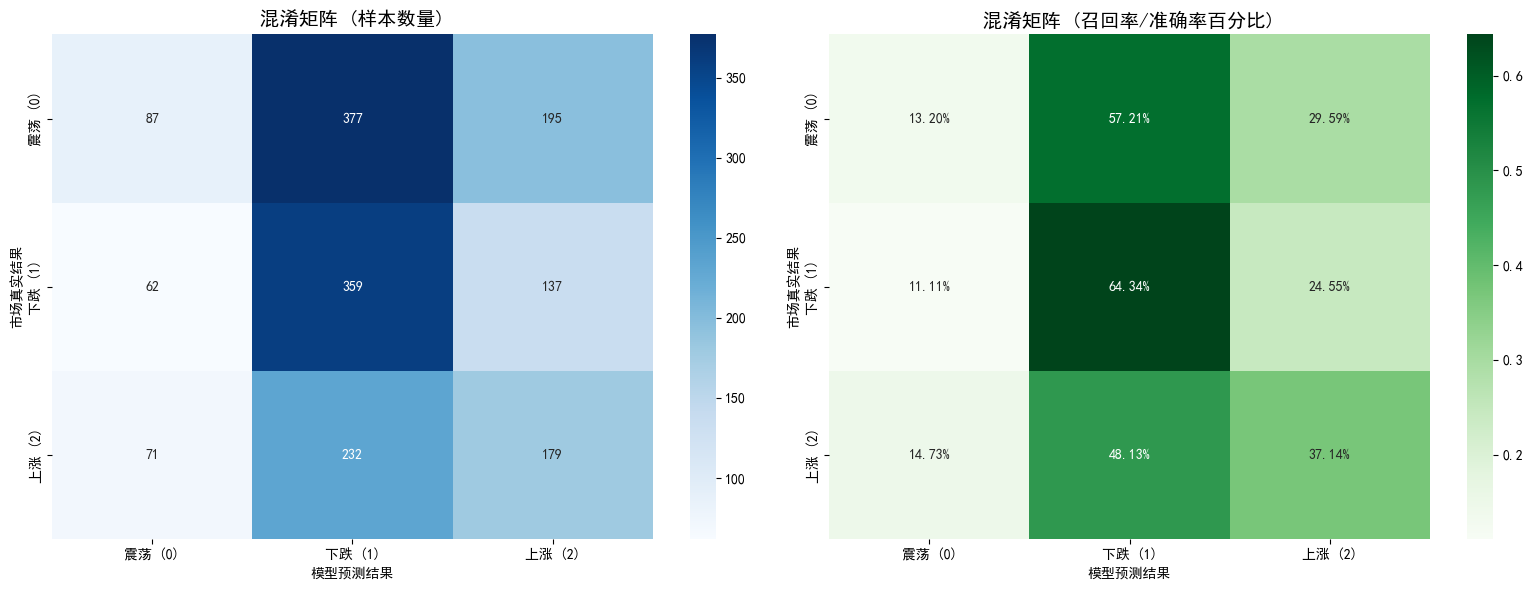


[实战模拟信号质量分析]
做多信号(预测2) 胜率: 35.03% (共发出 511 次信号)
做空信号(预测1) 胜率: 37.09% (共发出 968 次信号)


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def evaluate_model_performance(model, X, y, test_size=0.2):
    """
    对金融模型进行严格的时间序列评估
    
    参数:
    model: 训练好的 LightGBM 模型
    X, y: 全量特征与标签
    test_size: 验证集比例 (默认最后 20% 的数据作为验证集)
    """
    
    # ==========================================
    # 1. 数据划分 (Time-Series Split)
    # ==========================================
    # 必须严格按时间切分，后 20% 作为"未见过的未来"
    split_point = int(len(X) * (1 - test_size))
    
    X_test = X.iloc[split_point:]
    y_test = y.iloc[split_point:]
    
    # 打印验证集的时间范围，确认没有穿越
    # (假设 X 的索引是时间)
    if isinstance(X.index, pd.DatetimeIndex):
        print(f"验证集时间范围: {X_test.index.min()} 至 {X_test.index.max()}")
    print(f"验证集样本数: {len(X_test)}")

    # ==========================================
    # 2. 模型预测
    # ==========================================
    print("\n正在进行预测...")
    y_pred = model.predict(X_test)
    
    # 如果模型支持输出概率，我们也可以看概率分布（可选）
    # y_prob = model.predict_proba(X_test)

    # ==========================================
    # 3. 核心指标统计
    # ==========================================
    print("\n" + "="*50)
    print(" >>> 模型最终性能评估报告 <<<")
    print("="*50)
    
    target_names = ['震荡 (0)', '下跌 (1)', '上涨 (2)']
    
    # (A) 详细分类报告
    # 这里包含了 Precision (查准率), Recall (召回率), F1-Score
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # (B) 关键单项指标
    # 在金融中，我们最看重 Precision（预测涨真的涨了吗？）
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    print(f"总体加权查准率 (Weighted Precision): {precision_weighted:.2%} (越高越好，代表虚假信号少)")
    print(f"总体加权 F1 分数 (Weighted F1):      {f1_weighted:.2%} (综合指标)")

    # ==========================================
    # 4. 可视化图表
    # ==========================================
    # 设置中文字体，防止乱码 (根据系统环境可能需要调整)
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 图表 1: 混淆矩阵 (绝对数量) ---
    # 作用：直观看到到底有多少个“震荡”被错判成了“上涨”
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=target_names, yticklabels=target_names)
    axes[0].set_title('混淆矩阵 (样本数量)', fontsize=14)
    axes[0].set_xlabel('模型预测结果')
    axes[0].set_ylabel('市场真实结果')

    # --- 图表 2: 混淆矩阵 (归一化比例) ---
    # 作用：查看每一类别的预测准确率 (Recall视角)
    # 比如：真实上涨的样本中，有多少比例被模型抓住了？
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
                xticklabels=target_names, yticklabels=target_names)
    axes[1].set_title('混淆矩阵 (召回率/准确率百分比)', fontsize=14)
    axes[1].set_xlabel('模型预测结果')
    axes[1].set_ylabel('市场真实结果')

    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # 5. 特别关注：信号质量分析
    # ==========================================
    # 专门统计模型发出“买入(2)”和“卖出(1)”信号时的胜率
    print("\n[实战模拟信号质量分析]")
    
    # 统计预测为“上涨”的样本中，真实也是“上涨”的比例
    pred_up_mask = (y_pred == 2)
    if np.sum(pred_up_mask) > 0:
        real_up_in_pred = y_test[pred_up_mask]
        win_rate_up = np.mean(real_up_in_pred == 2)
        print(f"做多信号(预测2) 胜率: {win_rate_up:.2%} (共发出 {np.sum(pred_up_mask)} 次信号)")
    else:
        print("做多信号(预测2) 胜率: N/A (模型未发出做多信号)")
        
    # 统计预测为“下跌”的样本中，真实也是“下跌”的比例
    pred_down_mask = (y_pred == 1)
    if np.sum(pred_down_mask) > 0:
        real_down_in_pred = y_test[pred_down_mask]
        win_rate_down = np.mean(real_down_in_pred == 1)
        print(f"做空信号(预测1) 胜率: {win_rate_down:.2%} (共发出 {np.sum(pred_down_mask)} 次信号)")
    else:
        print("做空信号(预测1) 胜率: N/A (模型未发出做空信号)")

# ==========================================
# 执行代码
# ==========================================
# 假设 trained_model, X, y 已经存在于上下文中
if 'trained_model' in locals() and 'X' in locals() and 'y' in locals():
    evaluate_model_performance(trained_model, X, y)
else:
    print("提示：请先运行上一段代码以完成模型训练，生成 trained_model 变量。")